In [ ]:
# Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score

In [3]:
df = pd.read_csv('Housing.csv')
print(df)

        price  area  bedrooms  ...  parking  prefarea furnishingstatus
0    13300000  7420         4  ...        2       yes        furnished
1    12250000  8960         4  ...        3        no        furnished
2    12250000  9960         3  ...        2       yes   semi-furnished
3    12215000  7500         4  ...        3       yes        furnished
4    11410000  7420         4  ...        2        no        furnished
..        ...   ...       ...  ...      ...       ...              ...
540   1820000  3000         2  ...        2        no      unfurnished
541   1767150  2400         3  ...        0        no   semi-furnished
542   1750000  3620         2  ...        0        no      unfurnished
543   1750000  2910         3  ...        0        no        furnished
544   1750000  3850         3  ...        0        no      unfurnished

[545 rows x 13 columns]


In [4]:
x = df[['area']]
y = df['price']

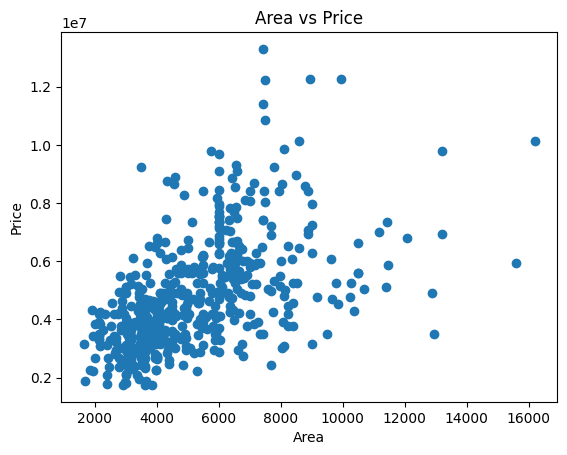

In [6]:
plt.scatter(x,y)
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs Price')
plt.show()

In [9]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
print(model.coef_)
print(model.intercept_)

[425.72984194]
2512254.2639593435


In [12]:
y_pred = model.predict(x_test)

In [13]:
print(mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

3675286604768.185
0.27287851871974644


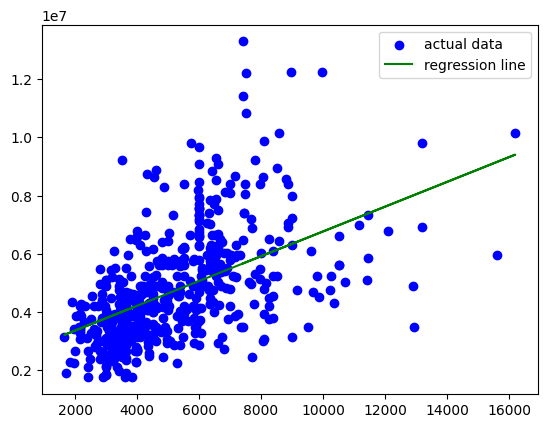

In [16]:
plt.scatter(x,y,label='actual data',c='b')
plt.plot(x,model.predict(x),label='regression line',c='g')
plt.legend()
plt.show()

In [22]:
new_hours = [[12],[13]]
new_pred = model.predict(new_hours)
print(new_pred)

[2517363.02206261 2517788.75190455]


c:\Users\MITAN TANK\Desktop\Programs\Python\Regression\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [23]:
# Non-Linear Regression

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score

In [26]:
df = pd.read_csv('diabetes_nonlinear.csv')
print(df)

          BMI  Disease_Progression
0    0.061696                151.0
1   -0.051474                 75.0
2    0.044451                141.0
3   -0.011595                206.0
4   -0.036385                135.0
..        ...                  ...
437  0.019662                178.0
438 -0.015906                104.0
439 -0.015906                132.0
440  0.039062                220.0
441 -0.073030                 57.0

[442 rows x 2 columns]


In [27]:
x = df[['BMI']]
y = df['Disease_Progression']

In [36]:
poly = PolynomialFeatures(degree=3)

In [38]:
x_poly = poly.fit_transform(x)

In [39]:
model = LinearRegression()
model.fit(x_poly,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
y_pred = model.predict(x_poly)

In [43]:
print(mean_squared_error(y,y_pred))
print(r2_score(y,y_pred))

3883.351178536732
0.34512199713015435


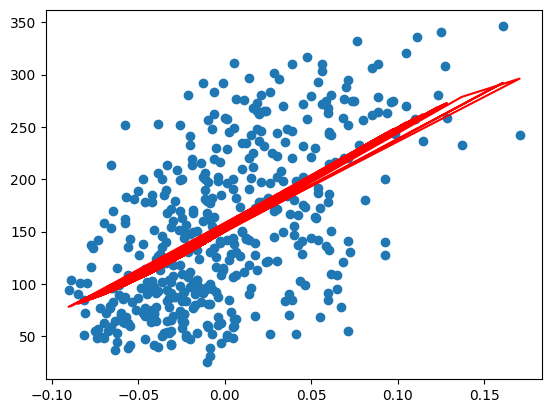

In [45]:
plt.scatter(x,y)
plt.plot(x.values.flatten(),y_pred,c='r')
plt.show()

In [46]:
new_x = [[0.05],[0.1],[0.15],[0.2]]
new_poly = poly.fit_transform(new_x)
new_pred = model.predict(new_poly)
print(new_pred)

[201.59950508 249.93490318 286.54056647 302.67388676]


In [48]:
# KNN

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [51]:
df = pd.read_csv('iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [52]:
x = df.drop(['Species' , 'Id'], axis=1)
y = df['Species']

In [54]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [56]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [58]:
y_pred = model.predict(x_test)

In [60]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [62]:
new_pred = model.predict([[5.1,3.5,1.4,0.2]])
print(new_pred)

['Iris-setosa']


c:\Users\MITAN TANK\Desktop\Programs\Python\Regression\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [64]:
# Logistic Regression

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [67]:
df = pd.read_csv("loan_approval_dataset.csv")
print(df)

    age  income  credit_score  loan_amount  years_employed  loan_approved
0    25   30000           580        10000               1              0
1    28   35000           600        12000               2              0
2    30   40000           620        15000               3              0
3    32   45000           650        18000               4              0
4    35   50000           670        20000               5              1
5    37   55000           690        22000               6              1
6    40   60000           710        25000               7              1
7    42   65000           720        27000               8              1
8    45   70000           740        30000              10              1
9    48   75000           760        32000              12              1
10   23   28000           560         9000               1              0
11   26   32000           590        11000               2              0
12   29   38000           610        1

In [69]:
x = df.drop(['loan_approved'],axis=1)
y = df['loan_approved']

In [71]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model = LogisticRegression()
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [73]:
y_pred = model.predict(x_test)

In [75]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

1.0
[[3 0]
 [0 3]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [83]:
new_pred = model.predict([[35,50000,670,2000,5]])
print(new_pred)

[1]


c:\Users\MITAN TANK\Desktop\Programs\Python\Regression\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [85]:
# SVC

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [89]:
df = pd.read_csv("student_admission_dataset.csv")
print(df.head())

   hours_studied  attendance  previous_score  assignments_completed  admission
0              2          60              55                      3          0
1              3          65              58                      4          0
2              4          70              60                      5          0
3              6          75              66                      6          1
4              7          78              70                      7          1


In [91]:
x = df.drop(['admission'],axis=1)
y = df['admission']

In [101]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model = SVC(kernel='linear')
model.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [104]:
y_pred = model.predict(x_test)

In [105]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

1.0
[[2]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



c:\Users\MITAN TANK\Desktop\Programs\Python\Regression\.venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [107]:
new_student = [[7, 80, 70, 7]]
prediction = model.predict(new_student)

print("\nAdmission Prediction:", prediction[0])


Admission Prediction: 1


c:\Users\MITAN TANK\Desktop\Programs\Python\Regression\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [109]:
# Decision Tree Classifier

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [113]:
df = pd.read_csv("employee_promotion_dataset.csv")
df.head()

,age,income,experience_years,education_level,hours_per_week,performance
0,24,32000,1,1,38,0
1,26,36000,2,2,40,0
2,28,42000,3,2,41,0
3,29,45000,4,2,42,0
4,31,52000,5,3,44,0


In [121]:
X = df.drop("performance", axis=1)
y = df["performance"]

In [125]:
x_train , x_test , y_train , y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = DecisionTreeClassifier(max_depth=4)
model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [127]:
y_pred = model.predict(x_test)

In [131]:
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


0.7857142857142857
[[4 1]
 [2 7]]
              precision    recall  f1-score   support

           0       0.67      0.80      0.73         5
           1       0.88      0.78      0.82         9

    accuracy                           0.79        14
   macro avg       0.77      0.79      0.78        14
weighted avg       0.80      0.79      0.79        14



In [133]:
new_employee = [[35, 70000, 8, 3, 45]]

prediction = model.predict(new_employee)

print("\nPredicted Performance:", prediction[0])


Predicted Performance: 1


c:\Users\MITAN TANK\Desktop\Programs\Python\Regression\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [135]:
# K-Means

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [140]:
df = pd.read_csv("customer_segmentation_dataset.csv")
df.head()

,CustomerID,Age,Annual_Income,Spending_Score
0,1,19,15000,39
1,2,21,15000,81
2,3,20,16000,6
3,4,23,16000,77
4,5,31,17000,40


In [143]:
x = df[['Annual_Income','Spending_Score']]

In [145]:
model = KMeans(n_clusters=5,random_state=42)

In [147]:
model.fit(x)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [151]:
df['cluster'] = model.predict(x) 
print(df.head())

   CustomerID  Age  Annual_Income  Spending_Score  cluster
0           1   19          15000              39        2
1           2   21          15000              81        2
2           3   20          16000               6        2
3           4   23          16000              77        2
4           5   31          17000              40        2


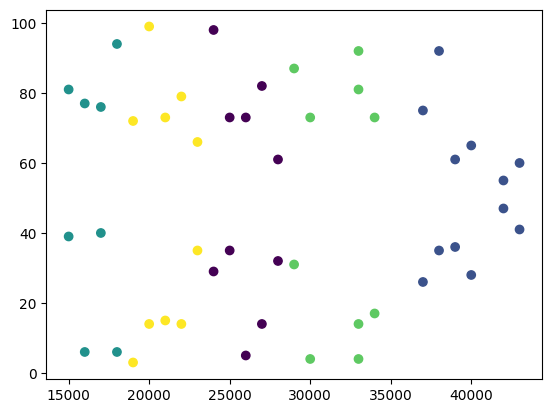

In [165]:
plt.scatter(df['Annual_Income'], df['Spending_Score'], c=df['cluster'])

plt.show()

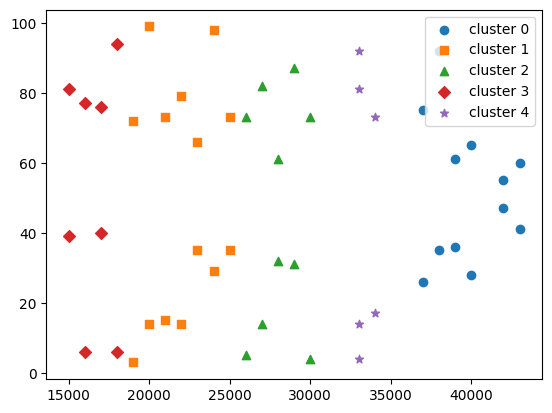

In [183]:
plt.scatter(df[df['cluster']==0]['Annual_Income'], df[df['cluster']==0]['Spending_Score'], marker='o', label='cluster 0')

plt.scatter(df[df['cluster']==1]['Annual_Income'], df[df['cluster']==1]['Spending_Score'], marker='s', label='cluster 1')

plt.scatter(df[df['cluster']==2]['Annual_Income'], df[df['cluster']==2]['Spending_Score'], marker='^', label='cluster 2')

plt.scatter(df[df['cluster']==3]['Annual_Income'], df[df['cluster']==3]['Spending_Score'], marker='D', label='cluster 3')

plt.scatter(df[df['cluster']==4]['Annual_Income'], df[df['cluster']==4]['Spending_Score'], marker='*', label='cluster 4')

plt.legend()

plt.show()

In [168]:
# Hierarchical Clustering

In [170]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

In [172]:
df = pd.read_csv('customer_hierarchical_dataset.csv')
df.head()

,CustomerID,Age,Annual_Income,Spending_Score
0,1,19,15000,39
1,2,21,15000,81
2,3,20,16000,6
3,4,23,16000,77
4,5,31,17000,40


In [173]:
x = df[['Annual_Income','Spending_Score']]

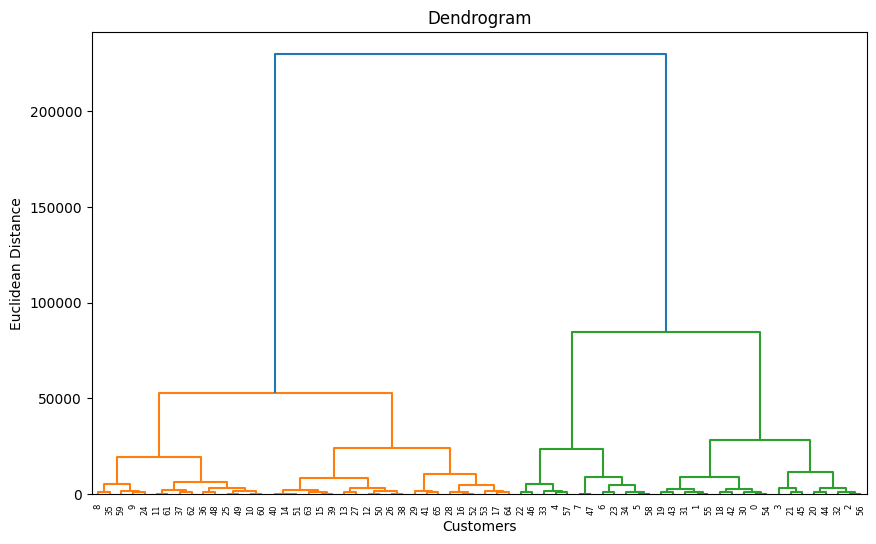

In [176]:
plt.figure(figsize=(10,6))

dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

In [179]:
model = AgglomerativeClustering(n_clusters=5)
data = model.fit_predict(x)
df['cluster'] = data

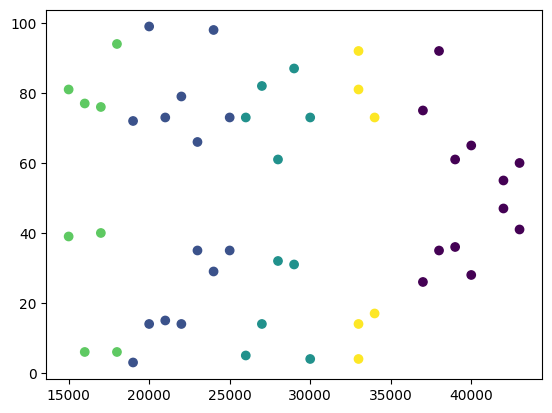

In [184]:
plt.scatter(df['Annual_Income'], df['Spending_Score'], c=df['cluster'])
plt.show()

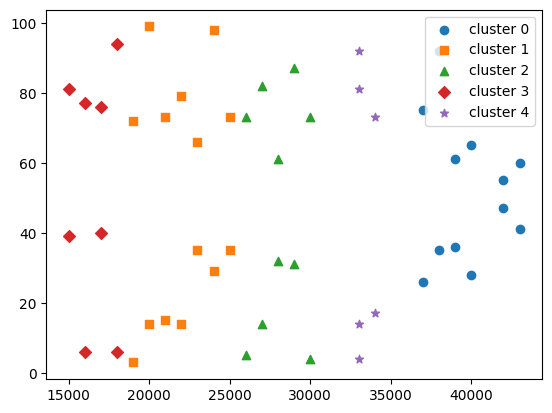

In [185]:
plt.scatter(df[df['cluster']==0]['Annual_Income'], df[df['cluster']==0]['Spending_Score'], marker='o', label='cluster 0')

plt.scatter(df[df['cluster']==1]['Annual_Income'], df[df['cluster']==1]['Spending_Score'], marker='s', label='cluster 1')

plt.scatter(df[df['cluster']==2]['Annual_Income'], df[df['cluster']==2]['Spending_Score'], marker='^', label='cluster 2')

plt.scatter(df[df['cluster']==3]['Annual_Income'], df[df['cluster']==3]['Spending_Score'], marker='D', label='cluster 3')

plt.scatter(df[df['cluster']==4]['Annual_Income'], df[df['cluster']==4]['Spending_Score'], marker='*', label='cluster 4')

plt.legend()

plt.show()

In [ ]:
# Density_Based_Clustering

In [186]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [188]:
df = pd.read_csv('customer_density_dataset.csv')
df.head()

,CustomerID,Annual_Income,Spending_Score
0,1,15000,39
1,2,15000,81
2,3,16000,6
3,4,16000,77
4,5,17000,40


In [191]:
x = df[['Annual_Income','Spending_Score']]

In [194]:
scale = StandardScaler()
x_scale = scale.fit_transform(x)

In [195]:
model = DBSCAN(eps=0.5, min_samples=5)

data = model.fit_predict(x_scale)

df['Cluster'] = data

print(df.head())

   CustomerID  Annual_Income  Spending_Score  Cluster
0           1          15000              39       -1
1           2          15000              81        0
2           3          16000               6        1
3           4          16000              77        0
4           5          17000              40       -1


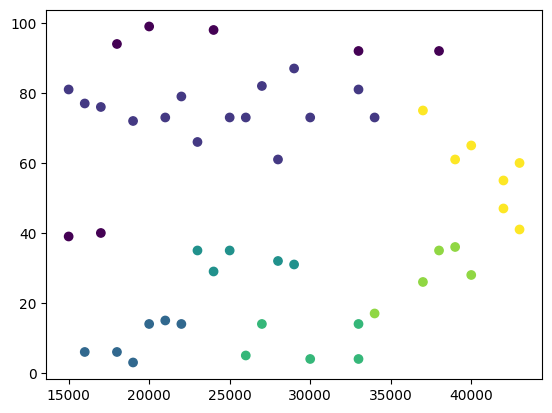

In [198]:
plt.scatter(df['Annual_Income'], df['Spending_Score'], c=df['Cluster'])

plt.show()